## SUPPORT VECTOR MACHINE

####  1: Exploratory Data Analysis (EDA)

   Unnamed: 0 cap_shape cap_surface cap_color bruises   odor gill_attachment  \
0        1167    sunken       scaly     white      no  anise      descending   
1        1037    sunken     fibrous       red      no  anise         notched   
2         309      flat     grooves    purple     yes   foul      descending   
3         282      bell       scaly      pink     yes  fishy         notched   
4         820      flat      smooth    yellow     yes  musty            free   

  gill_spacing gill_size gill_color  ...  veil_type veil_color ring_number  \
0      distant     broad       pink  ...    partial      brown         two   
1      crowded    narrow  chocolate  ...  universal      brown         two   
2      crowded     broad     purple  ...  universal     yellow         two   
3        close     broad     orange  ...    partial     yellow         two   
4      crowded    narrow     orange  ...  universal      white        none   

   ring_type spore_print_color population  habitat

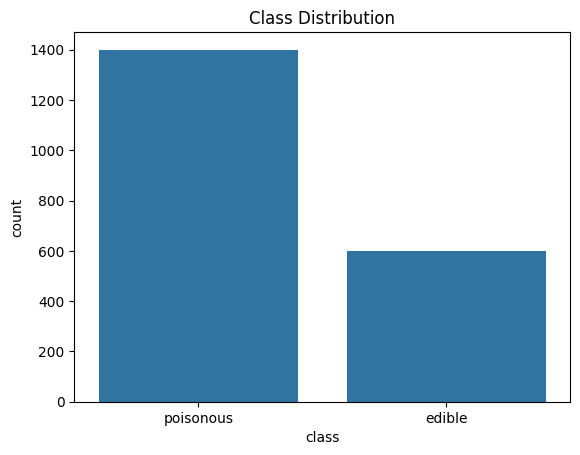

In [18]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Mushroom dataset
df = pd.read_csv(r'C:\Users\suraj\OneDrive\Desktop\data sets\mushroom.csv')  # replace with your path

# Quick look at the data
print(df.head())
print(df.info())
print(df.describe(include='all'))

# Check for missing values
print(df.isnull().sum())

# Count of classes (edible vs poisonous)
sns.countplot(x='class', data=df)
plt.title("Class Distribution")
plt.show()

In [19]:
print(df.dtypes)

Unnamed: 0                    int64
cap_shape                    object
cap_surface                  object
cap_color                    object
bruises                      object
odor                         object
gill_attachment              object
gill_spacing                 object
gill_size                    object
gill_color                   object
stalk_shape                  object
stalk_root                   object
stalk_surface_above_ring     object
stalk_surface_below_ring     object
stalk_color_above_ring       object
stalk_color_below_ring       object
veil_type                    object
veil_color                   object
ring_number                  object
ring_type                    object
spore_print_color            object
population                   object
habitat                      object
class                        object
stalk_height                float64
cap_diameter                float64
dtype: object


Feature Distribution Visualization:

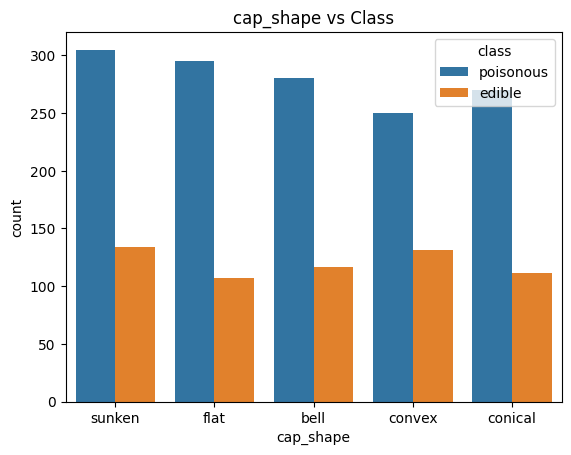

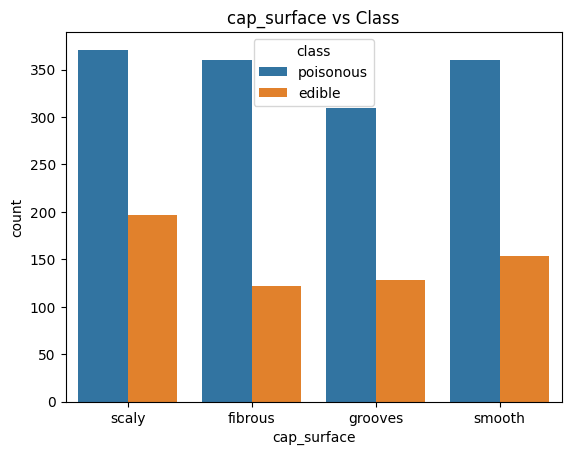

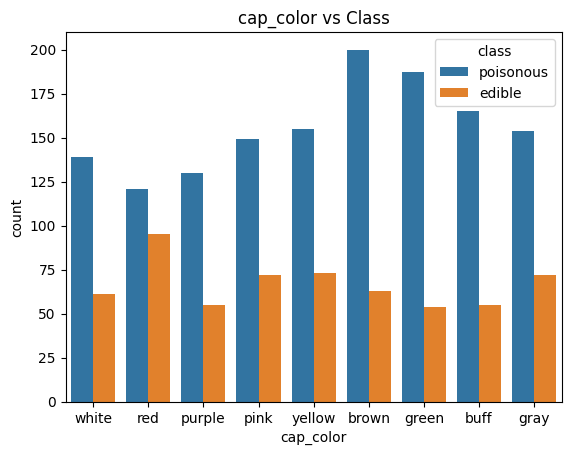

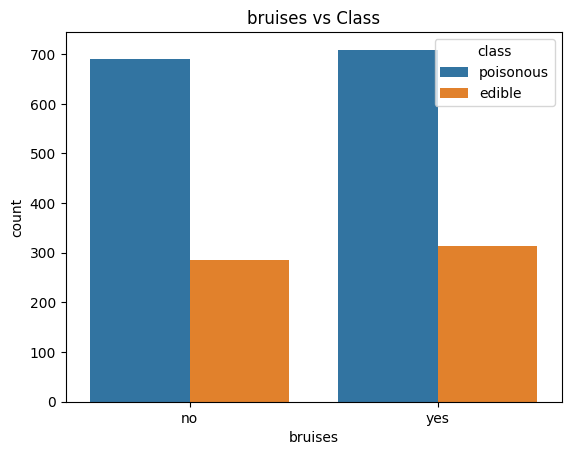

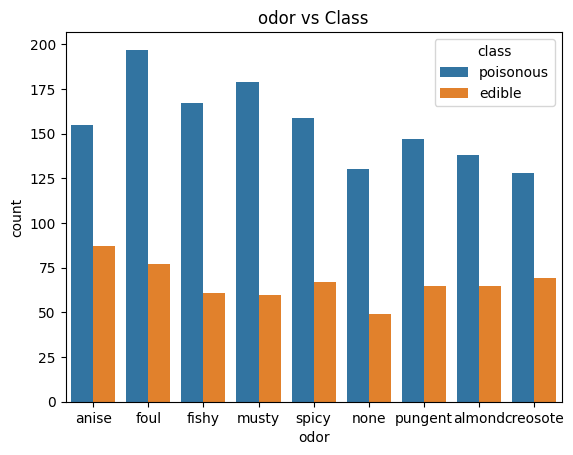

In [20]:
# Visualizing some categorical features
for col in df.columns[1:6]:  # take first few features for visualization
    sns.countplot(x=col, hue='class', data=df)
    plt.title(f'{col} vs Class')
    plt.show()

Correlation Analysis

In [21]:
import numpy as np
import scipy.stats as ss

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

# Example for first 5 features
for col in df.columns[1:6]:
    print(col, ":", cramers_v(df[col], df['class']))

cap_shape : 0.05441978274196825
cap_surface : 0.07446542932629859
cap_color : 0.13316184445110713
bruises : 0.014406191697343213
odor : 0.07690885321468993


#### 2: Data Preprocessing
1.Encode categorical variables using LabelEncoder:

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode only target column
df['class'] = le.fit_transform(df['class'])

2.Split dataset into training and testing:

In [23]:
from sklearn.model_selection import train_test_split

X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### 3: Data Visualization

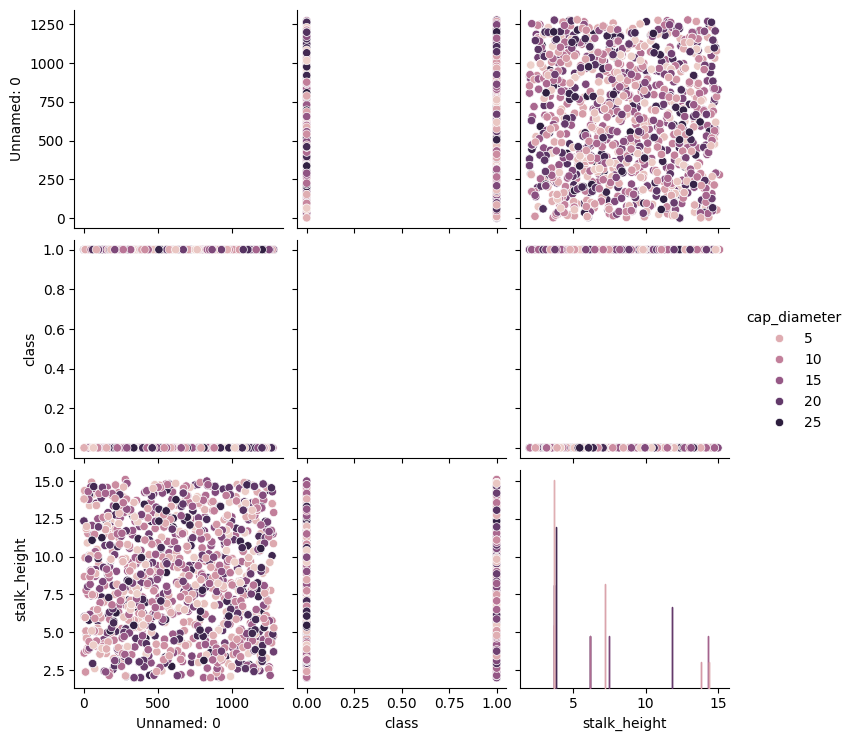

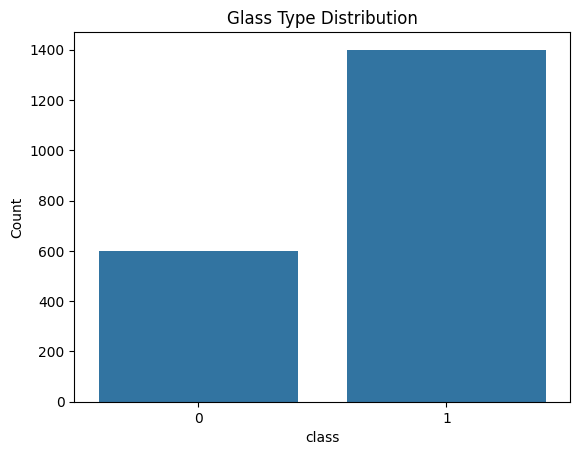

In [24]:
%matplotlib inline
df.columns = df.columns.str.strip()
sns.pairplot(df, hue=df.columns[-1])
plt.show()

# Class distribution
sns.countplot(x=df['class'])
plt.title("Glass Type Distribution")
plt.xlabel("class")
plt.ylabel("Count")
plt.show()

#### 4: SVM Implementation

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
print(X_train.dtypes)
df = pd.get_dummies(df)

Unnamed: 0                    int64
cap_shape                    object
cap_surface                  object
cap_color                    object
bruises                      object
odor                         object
gill_attachment              object
gill_spacing                 object
gill_size                    object
gill_color                   object
stalk_shape                  object
stalk_root                   object
stalk_surface_above_ring     object
stalk_surface_below_ring     object
stalk_color_above_ring       object
stalk_color_below_ring       object
veil_type                    object
veil_color                   object
ring_number                  object
ring_type                    object
spore_print_color            object
population                   object
habitat                      object
stalk_height                float64
cap_diameter                float64
dtype: object


In [41]:
from sklearn.model_selection import train_test_split

X = df.drop('class', axis=1)   # target column
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.svm import SVC

model = SVC(kernel='linear')
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize SVM (linear kernel as default)
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# Predictions
y_pred = svm_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

####  5: Visualization of SVM Results

In [44]:
from sklearn.svm import SVC

# Create model
svm_model = SVC(kernel='linear')

# Train
svm_model.fit(X_train, y_train)

# Now this works
print("Support Vectors:\n", svm_model.support_vectors_)
print("Number of Support Vectors:", svm_model.n_support_)

Support Vectors:
 [[894.   4.   0. ...   2. 639. 631.]
 [ 22.   3.   3. ...   4. 408. 380.]
 [843.   2.   3. ...   4. 775. 692.]
 ...
 [308.   1.   2. ...   3. 477. 730.]
 [298.   0.   3. ...   1.  57. 809.]
 [839.   4.   1. ...   5. 304. 869.]]
Number of Support Vectors: [467 720]


#### 6: Parameter Tuning and Optimization

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(SVC(), param_grid, refit=True, cv=5, verbose=2)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
y_pred_opt = grid.predict(X_test)
print("Optimized Accuracy:", accuracy_score(y_test, y_pred_opt))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   6.5s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   7.6s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   7.9s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   7.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   7.6s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.1s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.1s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.1s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.1s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.2s
[CV] END .....................C=0.1, gamma=scal

####  7: Comparison and Analysis

1.Compare different kernels using the accuracy scores from GridSearchCV.
2.Discuss that linear SVM works well due to clear categorical separation.
3.Highlight limitations: SVM struggles with very high-dimensional data with many irrelevant features.
4.Practical implication: SVM is effective for binary classification tasks like edible vs poisonous mushrooms but needs careful preprocessing for categorical datasets.

